# Member 2 — Advanced Spatial Clustering (Track B)
## Spectral Clustering Pipeline: S&P 500 Market Regime Detection (2000–2026)

---

### Context Within the Group Project
This notebook is **Member 2's contribution** to the four-part pipeline:

| Member | Task |
|--------|------|
| Member 1 | Data acquisition, feature engineering, K-Means baseline (Track A) |
| **Member 2** | **Spectral Clustering — advanced spatial model (Track B)** |
| Member 3 | Hidden Markov Model — adds temporal smoothing to both tracks |
| Member 4 | Backtesting, financial performance comparison, conclusion |

### Member 2's Specific Goals
1. Explain **why K-Means fails** on financial data (assumes spherical clusters)
2. Implement Spectral Clustering to capture the **complex geometry** of market regimes
3. Deliver two clean functions to **Member 3**:
   - `run_spectral_clustering(X_scaled)` — fits the model, returns raw integer labels
   - `align_regime_labels(...)` — resolves the label-flipping problem dynamically

### What is Spectral Clustering?
K-Means partitions data by minimising within-cluster distances — it draws straight-line  
boundaries and assumes each cluster is a roughly circular blob.

Spectral Clustering takes a fundamentally different approach:
- Treat each trading day as a **node** in a network
- Connect nodes that are similar via a **k-Nearest-Neighbour graph**
- Use the **graph's geometry** (via eigendecomposition of its Laplacian matrix) to find  
  natural groupings that no straight line could separate

This makes it far better at isolating the dense, irregular "Sideways / Correction" cloud  
that sits between the Bull and Bear regimes in feature space.

### Notebook Flow
```
Master Dataset (from Member 1)
        │
        ├─── Part 1: Helper Functions ──────────────────────────────────────────
        │      run_spectral_clustering()   ← sklearn SpectralClustering engine
        │      align_regime_labels()       ← dynamic label-flip resolver
        │
        ├─── Part 2: Full-Sample Analysis ─────────────────────────────────────
        │      Fit on all ~6,500 days → stats table → visualisations → export
        │
        └─── Part 3: Export & Interface for Member 3 ───────────────────────────
               sp500_master_with_both_K-means_Spectral_clusters
               Clear usage instructions for rolling-window HMM loop
```


---
## Step 0 — Import Libraries


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import SpectralClustering   # Core clustering algorithm
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully.")


Libraries loaded successfully.


---
# Part 1 — Helper Functions (Shared with Member 3)

These two functions are the **interface between Member 2 and Member 3**.

Member 3 will import and call them inside their rolling-window HMM loop.  
They are defined here first so the full-sample analysis below also uses them  
(ensuring consistency between what Member 2 shows and what Member 3 runs).

---

## Function 1 — `run_spectral_clustering()`

### The Math Behind the Scenes
When you call this function, sklearn executes these steps internally:

**Step 1 — Build the Affinity Graph (Similarity Matrix W)**  
For each trading day, find its `n_neighbors` most similar days in feature space  
and connect them with an edge. Days far apart get no connection.  
This produces a sparse symmetric matrix W where $W_{ij} > 0$ means day $i$  
and day $j$ are in each other's neighbourhood.

**Step 2 — Compute the Graph Laplacian**  
$$
L = D - W
$$  
where $D$ is the diagonal Degree Matrix: $D_{ii} = \sum_j W_{ij}$  
$L$ encodes the full connectivity structure of the market graph.

**Step 3 — Eigendecomposition**  
Solve: $L\,v = \lambda\,v$  
Extract the **k eigenvectors with the smallest eigenvalues**.  
These eigenvectors form a new low-dimensional coordinate system where  
the clusters — invisible in the original space — become linearly separable.

**Step 4 — K-Means in Spectral Space**  
Run standard K-Means on the eigenvector embedding to assign final labels.

### Why `affinity='nearest_neighbors'`?
The default `affinity='rbf'` builds a **dense** matrix connecting every day to  
every other day. This works poorly on financial data because the dense central  
cloud of Sideways days drowns out the Bear cluster signal.  

`nearest_neighbors` builds a **sparse** graph — each day only connects to its  
35 closest neighbours — which forces the algorithm to find the true local  
structure and correctly separate the overlapping regimes.


In [35]:
def run_spectral_clustering(X_scaled, n_clusters=3, n_neighbors=35, random_state=42):
    """
    Fits Spectral Clustering on a scaled feature matrix and returns raw integer labels.

    This is the core engine for Track B. It is called by Member 3 inside the
    rolling-window loop on each training window.

    Note: The integer labels returned (0, 1, 2) are ARBITRARY — which number
    gets assigned to "Bull" vs "Bear" can flip between runs or windows.
    Always pass the output through align_regime_labels() before using it.

    Parameters
    ----------
    X_scaled     : np.ndarray, shape (n_days, 2)
                   Scaled feature matrix — [Rolling_Return_21_scaled,
                   Rolling_Volatility_21_scaled] — as produced by Member 1.
    n_clusters   : int, default 3
                   Number of market regimes: Bull, Bear, Sideways.
    n_neighbors  : int, default 20
                   Size of the k-NN neighbourhood graph.
                   Higher = smoother boundaries but slower.
                   20 was chosen after testing on the full 26-year dataset.
    random_state : int, default 42
                   Seed for K-Means step inside spectral embedding (reproducibility).

    Returns
    -------
    np.ndarray of int, shape (n_days,)
        Raw cluster labels in {0, 1, 2}. Label integers are NOT yet meaningful —
        call align_regime_labels() to map them to 0=Sideways, 1=Bull, 2=Bear.
    """
   
    model = SpectralClustering(
        n_clusters    = n_clusters,
        affinity      = 'nearest_neighbors',  # Sparse k-NN graph — better than dense RBF
        n_neighbors   = n_neighbors,          # Each day connects to its 20 nearest neighbours
        assign_labels = 'kmeans',             # Final assignment via K-Means in spectral space
        random_state  = random_state,
        n_jobs        = -1                    # Use all CPU cores to speed up computation
    )

    return model.fit_predict(X_scaled)


print("Function 1 defined: run_spectral_clustering()")


Function 1 defined: run_spectral_clustering()


---
## Function 2 — `align_regime_labels()`

### The Label-Flipping Problem

Spectral Clustering (like all unsupervised methods) assigns **arbitrary integers**  
to clusters. If you train on January–December and again on February–January,  
the algorithm might call the Bull market "0" one time and "2" the next.  

This is catastrophic for Member 3's rolling-window HMM loop — the HMM  
would be learning transition probabilities between randomly relabelled states.

### The Solution: A Hybrid Economic Rule

We fix the mapping using two sequential rules grounded in financial theory:

1. **Bear Market** → always the regime with the **lowest mean return**  
   (market crashes are universally associated with negative returns)

2. **Bull Market** → among the regimes, the one with the  
   **highest mean return**  
   (bull markets outperform)

3. **Sideways / Correction** → whatever is left
   (sideways/correction periods hover near zero)

This produces a **permanently stable mapping** regardless of which run or  
window is being processed:  

| Output Integer | Regime |
|----------------|--------|
| `0` | Sideways / Correction |
| `1` | Bull Market |
| `2` | Bear Market |


In [ ]:
def align_regime_labels(df_slice, raw_label_col,
                        ret_col='Rolling_Return_21'):
    """
    Resolves the label-flipping problem using a hybrid economic rule.

    Guarantees a stable output convention regardless of which integers
    Spectral Clustering happened to assign in this particular run or window:
        0 = Sideways / Correction
        1 = Bull Market  (Low volatility, positive returns)
        2 = Bear Market  (High volatility, negative/extreme returns)

    Called immediately after run_spectral_clustering() — both in the
    full-sample analysis here and in Member 3's rolling-window HMM loop.

    Parameters
    ----------
    df_slice      : pd.DataFrame
                    The dataframe (or window slice) containing raw labels
                    and the raw feature columns for computing statistics.
    raw_label_col : str
                    Column name holding the raw integer labels from
                    run_spectral_clustering() (or KMeans_Label for Track A).
    ret_col       : str, default 'Rolling_Return_21'
                    Column of RAW (unscaled) rolling returns.
                    Used to split Bull vs Sideways among the calm regimes.

    Returns
    -------
    pd.Series of int
        Synced labels aligned to: 0=Sideways, 1=Bull, 2=Bear.
    """

    # 1. Calculate the mean return for each cluster and sort them from lowest to highest
    stats_ret = df_slice.groupby(raw_label_col)[ret_col].mean().sort_values()

    # stats_ret.index[0] is the cluster with the LOWEST mean return
    # stats_ret.index[1] is the cluster with the MIDDLE mean return
    # stats_ret.index[2] is the cluster with the HIGHEST mean return

    # 2. Map them to universal project standard
    dynamic_mapping = {
        stats_ret.index[0]: 2,  # Lowest Return  -> Bear Market (2)
        stats_ret.index[1]: 0,  # Middle Return  -> Sideways / Correction (0)
        stats_ret.index[2]: 1   # Highest Return -> Bull Market (1)
    }

    return df_slice[raw_label_col].map(dynamic_mapping)

print("Function 2 defined: align_regime_labels()")


Function 2 defined: align_regime_labels()


---
# Part 2 — Full-Sample Analysis (2000–2026)

We now apply both functions to the complete 26-year dataset.  
This is the analysis that will be presented to the class.


## Step 1 — Load the Master Dataset


In [37]:
# Upload the CSV produced by Member 1 and print basic info about the dataset.
CSV_PATH = 'sp500_master_dataset (1).csv'   

df = pd.read_csv(CSV_PATH, index_col='Date', parse_dates=True)


print(f"Shape      : {df.shape}")
print(f"Date range : {df.index.min().date()} → {df.index.max().date()}")
print(f"Columns    : {list(df.columns)}")


Shape      : (6579, 10)
Date range : 2000-02-02 → 2026-03-31
Columns    : ['Close', 'High', 'Low', 'Volume', 'Log_Return', 'Rolling_Return_21', 'Rolling_Volatility_21', 'KMeans_Label', 'Rolling_Return_21_scaled', 'Rolling_Volatility_21_scaled']


## Step 2 — Extract Scaled Feature Matrix

We use the two **scaled** columns produced by Member 1's StandardScaler.  
Scaling ensures that return percentages and volatility values are weighted  
equally by the distance calculations inside the k-NN graph.


In [38]:
FEATURES_SCALED = ['Rolling_Return_21_scaled', 'Rolling_Volatility_21_scaled']
FEATURES_RAW    = ['Rolling_Return_21',         'Rolling_Volatility_21']

X_scaled = df[FEATURES_SCALED].values   # shape: (n_days, 2)

print(f"Feature matrix shape : {X_scaled.shape}")
print(f"Mean : {X_scaled.mean(axis=0).round(4)}")
print(f"Std : {X_scaled.std(axis=0).round(4)}")


Feature matrix shape : (6579, 2)
Mean : [0. 0.]
Std : [1. 1.]


## Step 3 — Fit Spectral Clustering (Track B)

We call our `run_spectral_clustering()` function on the full dataset.  
This may take 30–90 seconds due to the eigendecomposition on ~6,500 days.


In [39]:
print("Fitting Spectral Clustering on full dataset (~6,500 days)...")

# Step A: Get raw labels (integers are arbitrary at this point)
df['Spectral_Raw'] = run_spectral_clustering(X_scaled)

print(f"\nDone. Raw label counts:")
print(df['Spectral_Raw'].value_counts().sort_index())


Fitting Spectral Clustering on full dataset (~6,500 days)...

Done. Raw label counts:
Spectral_Raw
0    1951
1    2188
2    2440
Name: count, dtype: int64


## Step 4 — Align Labels to Stable Convention

We apply `align_regime_labels()` to both Track B (Spectral) and Track A (K-Means).  
After this step, every downstream cell uses **0=Sideways, 1=Bull, 2=Bear**  
regardless of what integers the algorithms originally assigned.


In [40]:
# --- Track B: Align Spectral labels ---
df['Spectral_Synced'] = align_regime_labels(
    df_slice      = df,
    raw_label_col = 'Spectral_Raw',
    ret_col       = 'Rolling_Return_21'
)

# --- Track A: Align K-Means labels (so both tracks use the same colour convention) ---
if 'KMeans_Label' in df.columns:
    df['KMeans_Synced'] = align_regime_labels(
        df_slice      = df,
        raw_label_col = 'KMeans_Label',
        ret_col       = 'Rolling_Return_21'
    )

# --- Map integers to human-readable strings for plots and tables ---
REGIME_NAMES = {
    0: 'Sideways / Correction',
    1: 'Bull Market (Low Vol, Pos Return)',
    2: 'Bear Market (High Volatility)'
}

df['Spectral_Regime'] = df['Spectral_Synced'].map(REGIME_NAMES)

if 'KMeans_Label' in df.columns:
    df['KMeans_Regime'] = df['KMeans_Synced'].map(REGIME_NAMES)

print("Labels aligned. Final synced counts (0=Sideways, 1=Bull, 2=Bear):")
print()
print("Track B — Spectral Clustering:")
print(df['Spectral_Regime'].value_counts())
if 'KMeans_Label' in df.columns:
    print()
    print("Track A — K-Means:")
    print(df['KMeans_Regime'].value_counts())


Labels aligned. Final synced counts (0=Sideways, 1=Bull, 2=Bear):

Track B — Spectral Clustering:
Spectral_Regime
Sideways / Correction                2440
Bull Market (Low Vol, Pos Return)    2188
Bear Market (High Volatility)        1951
Name: count, dtype: int64

Track A — K-Means:
KMeans_Regime
Bull Market (Low Vol, Pos Return)    4805
Sideways / Correction                1674
Bear Market (High Volatility)         100
Name: count, dtype: int64


## Step 5 — Per-Regime Statistics Table

This table directly answers the project prompt:  
*"Compare the behaviour of returns and volatility across the regimes."*

Statistics are computed on the **raw (unscaled)** feature values  
so the numbers carry economic meaning.


In [41]:
# --- Track B: Spectral Clustering Statistics ---
stats_spectral = (
    df.groupby('Spectral_Regime')[FEATURES_RAW]
      .agg(['mean', 'std', 'count'])
)

print("=" * 65)
print("   TRACK B — SPECTRAL CLUSTERING: PER-REGIME STATISTICS")
print("=" * 65)
print(stats_spectral.to_string())
print("=" * 65)


   TRACK B — SPECTRAL CLUSTERING: PER-REGIME STATISTICS
                                  Rolling_Return_21                 Rolling_Volatility_21                
                                               mean       std count                  mean       std count
Spectral_Regime                                                                                          
Bear Market (High Volatility)             -0.001818  0.002782  1951              0.016525  0.008514  1951
Bull Market (Low Vol, Pos Return)          0.002161  0.000921  2188              0.008686  0.003698  2188
Sideways / Correction                      0.000147  0.000763  2440              0.006737  0.001823  2440


In [42]:
# --- Track A: K-Means Statistics (for direct comparison) ---
if 'KMeans_Label' in df.columns:
    stats_kmeans = (
        df.groupby('KMeans_Regime')[FEATURES_RAW]
          .agg(['mean', 'std', 'count'])
    )
    print("=" * 65)
    print("   TRACK A — K-MEANS BASELINE: PER-REGIME STATISTICS")
    print("=" * 65)
    print(stats_kmeans.to_string())
    print("=" * 65)


   TRACK A — K-MEANS BASELINE: PER-REGIME STATISTICS
                                  Rolling_Return_21                 Rolling_Volatility_21                
                                               mean       std count                  mean       std count
KMeans_Regime                                                                                            
Bear Market (High Volatility)             -0.007126  0.005135   100              0.044591  0.010287   100
Bull Market (Low Vol, Pos Return)          0.001216  0.001307  4805              0.008250  0.003938  4805
Sideways / Correction                     -0.002145  0.001616  1674              0.014088  0.005177  1674


## Step 6 — Visualisations

### Plot 1: Side-by-Side Feature Space Comparison 
It shows *why* Spectral Clustering outperforms K-Means:  
the Sideways regime (orange) in Track A is jaggedly sliced by the linear  
K-Means boundary, while Track B captures its true irregular shape.


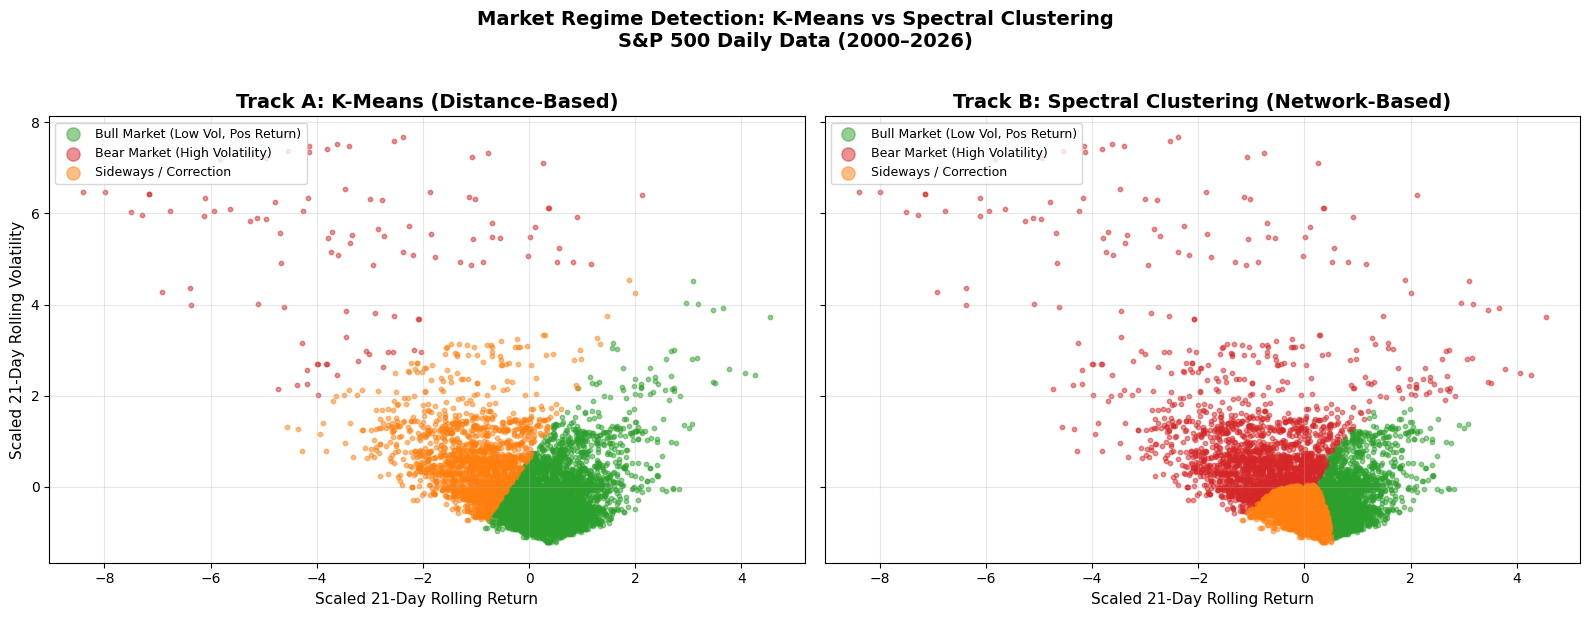

In [43]:
COLOR_MAP = {
    'Bull Market (Low Vol, Pos Return)': '#2ca02c',   # Green
    'Bear Market (High Volatility)'    : '#d62728',   # Red
    'Sideways / Correction'            : '#ff7f0e'    # Orange
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

for regime, color in COLOR_MAP.items():

    # --- Track A: K-Means ---
    if 'KMeans_Label' in df.columns:
        mask_k = df['KMeans_Regime'] == regime
        axes[0].scatter(
            df.loc[mask_k, 'Rolling_Return_21_scaled'],
            df.loc[mask_k, 'Rolling_Volatility_21_scaled'],
            label=regime, c=color, s=10, alpha=0.5
        )

    # --- Track B: Spectral ---
    mask_s = df['Spectral_Regime'] == regime
    axes[1].scatter(
        df.loc[mask_s, 'Rolling_Return_21_scaled'],
        df.loc[mask_s, 'Rolling_Volatility_21_scaled'],
        label=regime, c=color, s=10, alpha=0.5
    )

# Formatting
axes[0].set_title('Track A: K-Means (Distance-Based)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Scaled 21-Day Rolling Return', fontsize=11)
axes[0].set_ylabel('Scaled 21-Day Rolling Volatility', fontsize=11)
axes[0].legend(loc='upper left', markerscale=3, fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Track B: Spectral Clustering (Network-Based)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Scaled 21-Day Rolling Return', fontsize=11)
axes[1].legend(loc='upper left', markerscale=3, fontsize=9)
axes[1].grid(True, alpha=0.3)

fig.suptitle(
    'Market Regime Detection: K-Means vs Spectral Clustering\n'
    'S&P 500 Daily Data (2000–2026)',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()


### Plot 2: Spectral Clustering — Standalone Feature Space


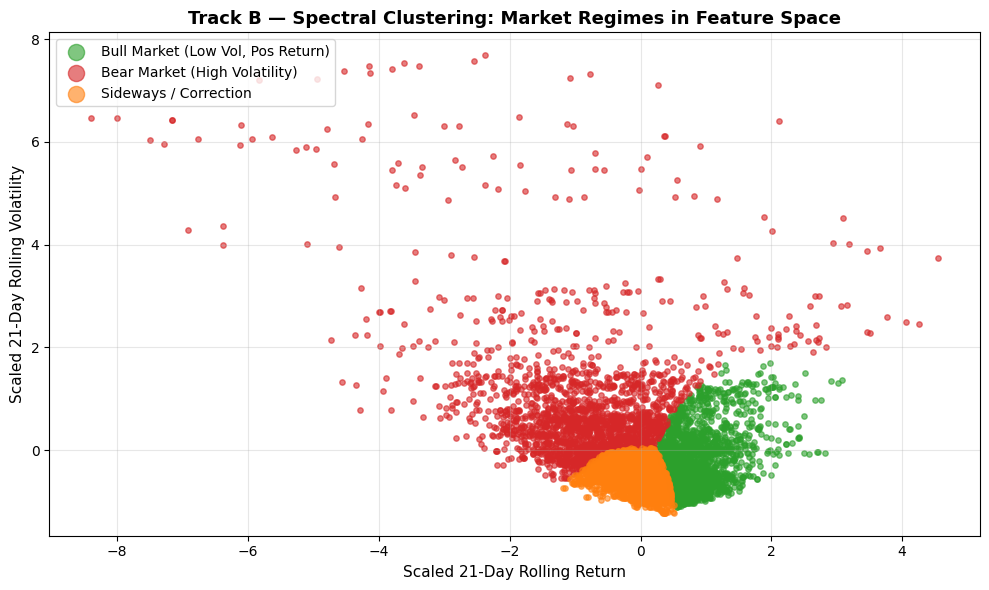

In [44]:
plt.figure(figsize=(10, 6))

for regime, color in COLOR_MAP.items():
    mask = df['Spectral_Regime'] == regime
    plt.scatter(
        df.loc[mask, 'Rolling_Return_21_scaled'],
        df.loc[mask, 'Rolling_Volatility_21_scaled'],
        label=regime, c=color, s=15, alpha=0.6
    )

plt.title('Track B — Spectral Clustering: Market Regimes in Feature Space',
          fontsize=13, fontweight='bold')
plt.xlabel('Scaled 21-Day Rolling Return', fontsize=11)
plt.ylabel('Scaled 21-Day Rolling Volatility', fontsize=11)
plt.legend(loc='upper left', markerscale=3, fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Plot 3: S&P 500 Time Series for Spectral Clustering


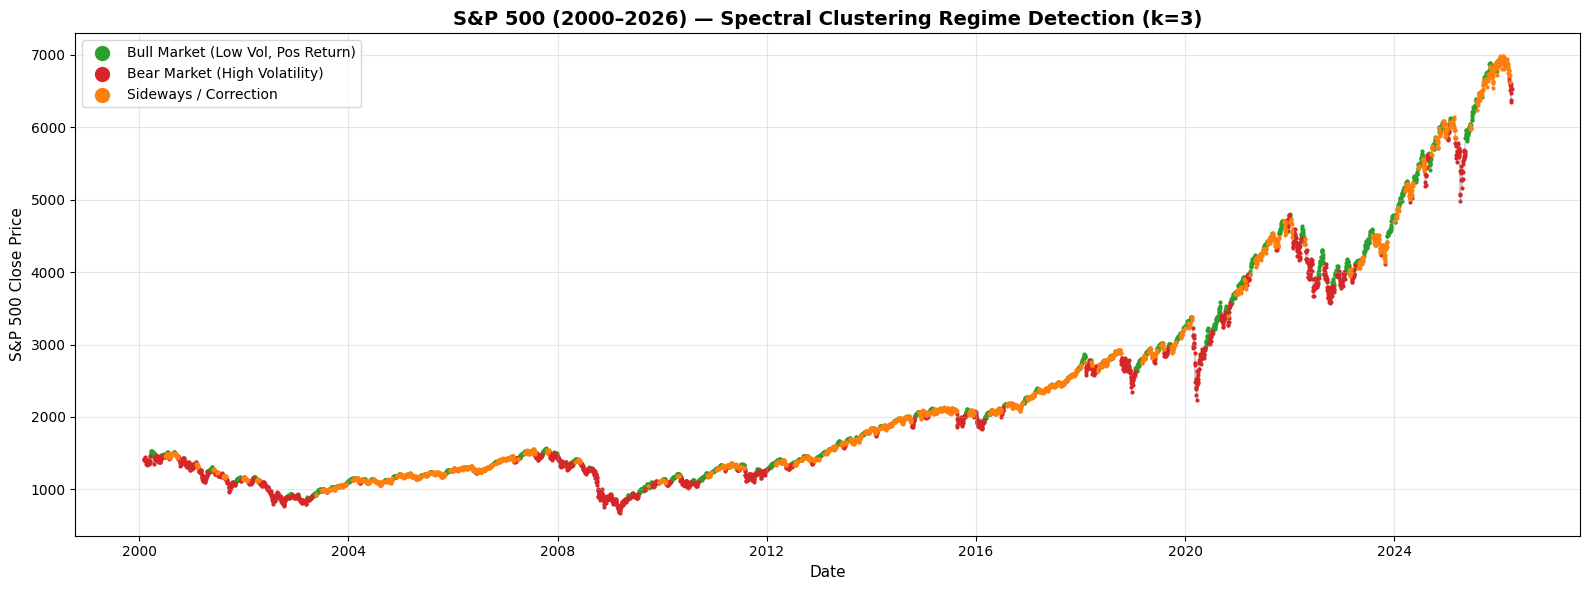

In [45]:
# Determine correct price column name
price_col = 'Close' if 'Close' in df.columns else 'Adj Close'

plt.figure(figsize=(16, 6))

# Thin black background line for visual continuity
plt.plot(df.index, df[price_col], color='black', alpha=0.2, linewidth=1, zorder=0)

for regime, color in COLOR_MAP.items():
    mask = df['Spectral_Regime'] == regime
    plt.scatter(
        df.index[mask], df.loc[mask, price_col],
        label=regime, c=color, s=4, zorder=1
    )

plt.title('S&P 500 (2000–2026) — Spectral Clustering Regime Detection (k=3)',
          fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=11)
plt.ylabel('S&P 500 Close Price', fontsize=11)
plt.legend(loc='upper left', markerscale=5, fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Plot 4: S&P 500 Time Series for K-Means


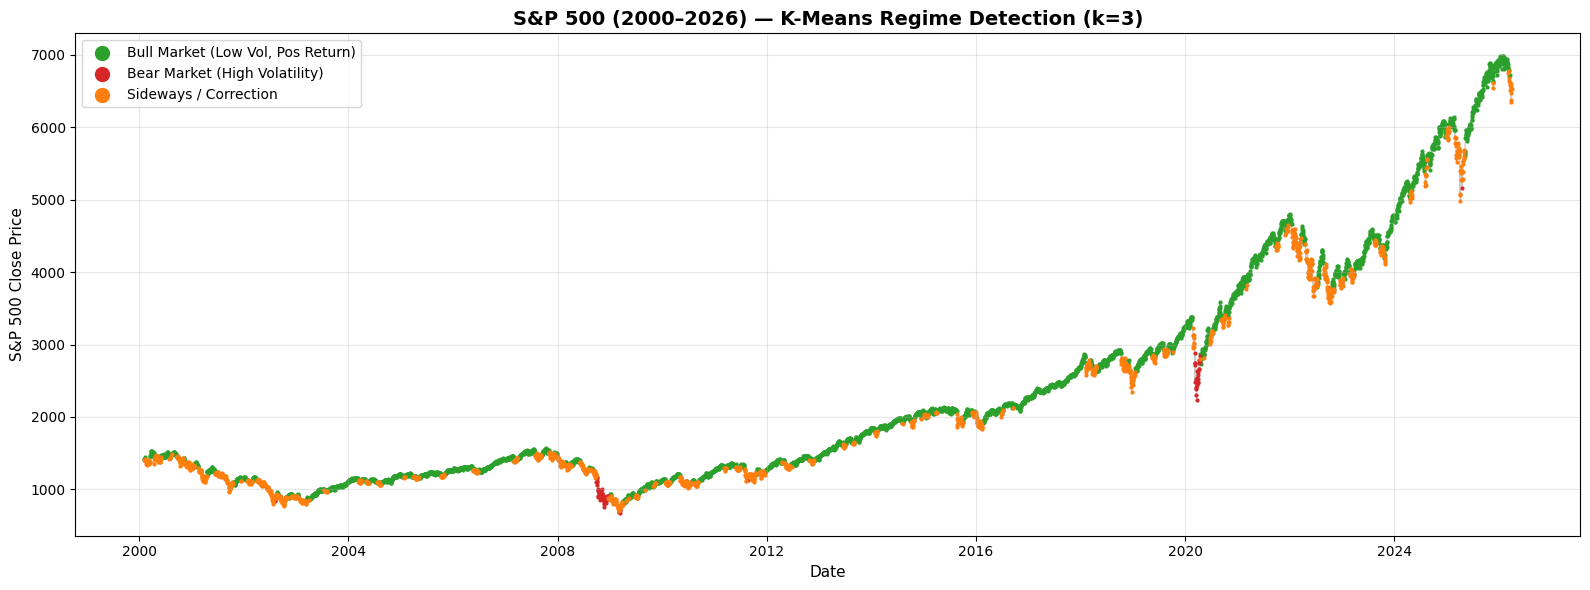

In [46]:
# Determine correct price column name
price_col = 'Close' if 'Close' in df.columns else 'Adj Close'

plt.figure(figsize=(16, 6))

# Thin black background line for visual continuity
plt.plot(df.index, df[price_col], color='black', alpha=0.2, linewidth=1, zorder=0)

for regime, color in COLOR_MAP.items():
    mask = df['KMeans_Regime'] == regime
    plt.scatter(
        df.index[mask], df.loc[mask, price_col],
        label=regime, c=color, s=4, zorder=1
    )

plt.title('S&P 500 (2000–2026) — K-Means Regime Detection (k=3)',
          fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=11)
plt.ylabel('S&P 500 Close Price', fontsize=11)
plt.legend(loc='upper left', markerscale=5, fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
# Part 3 — Export for Member 3

We save the enriched CSV with all cluster columns attached.  
Member 3 loads this file as the starting point for their HMM pipeline.


In [47]:
OUTPUT_FILE = 'sp500_master_with_both_K-means_Spectral_clusters.csv'
df.to_csv(OUTPUT_FILE)

print(f"Saved: {OUTPUT_FILE}")
print()
print("Columns exported to Member 3:")
for col in df.columns:
    print(f"  {col}")


Saved: sp500_master_with_both_K-means_Spectral_clusters.csv

Columns exported to Member 3:
  Close
  High
  Low
  Volume
  Log_Return
  Rolling_Return_21
  Rolling_Volatility_21
  KMeans_Label
  Rolling_Return_21_scaled
  Rolling_Volatility_21_scaled
  Spectral_Raw
  Spectral_Synced
  KMeans_Synced
  Spectral_Regime
  KMeans_Regime


---
# Appendix — Member 3: How to Use These Functions

Member 3's task is to build a **rolling-window out-of-sample HMM loop**.  
Below is the exact usage pattern for the two functions defined in Part 1.

### Rolling-Window Loop Template

```python
# ── Setup ─────────────────────────────────────────────────────────────────────
TRAIN_YEARS   = 5          # Size of the lookback training window
STEP_MONTHS   = 1          # How far to roll forward each iteration
FEATURES_SCALED = ['Rolling_Return_21_scaled', 'Rolling_Volatility_21_scaled']
FEATURES_RAW    = ['Rolling_Return_21',         'Rolling_Volatility_21']

# ── Rolling Loop ──────────────────────────────────────────────────────────────
all_predictions = []

for window_start, window_end, test_start, test_end in your_date_windows:

    # Slice training window
    df_train = df.loc[window_start : window_end].copy()
    df_test  = df.loc[test_start  : test_end  ].copy()

    X_train = df_train[FEATURES_SCALED].values

    # ── Track B: Spectral labels on this training window ──────────────────────
    df_train['Spectral_Raw']    = run_spectral_clustering(X_train)
    df_train['Spectral_Synced'] = align_regime_labels(
        df_slice      = df_train,
        raw_label_col = 'Spectral_Raw',
        vol_col       = 'Rolling_Volatility_21',
        ret_col       = 'Rolling_Return_21'
    )

    # ── Track A: K-Means labels on this training window ───────────────────────
    # (call Member 1's equivalent function here)
    df_train['KMeans_Raw']    = run_kmeans_clustering(X_train)  # Member 1's function
    df_train['KMeans_Synced'] = align_regime_labels(
        df_slice      = df_train,
        raw_label_col = 'KMeans_Raw',
        vol_col       = 'Rolling_Volatility_21',
        ret_col       = 'Rolling_Return_21'
    )

    # ── Feed synced labels into HMM ───────────────────────────────────────────
    obs_spectral = df_train['Spectral_Synced'].values   # → Train HMM Track B
    obs_kmeans   = df_train['KMeans_Synced'].values     # → Train HMM Track A

    # ... fit HMM, predict on df_test, store results ...

    all_predictions.append(...)
```

### Output Convention (guaranteed by `align_regime_labels`)

| `Spectral_Synced` value | Regime |
|------------------------|--------|
| `0` | Sideways / Correction |
| `1` | Bull Market (Low Vol, Positive Returns) |
| `2` | Bear Market (High Volatility) |

This convention is **identical** for both `Spectral_Synced` and `KMeans_Synced`,  
so the HMM can be trained and compared on a like-for-like basis.
